In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Set figure size default
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


### what is EDA?
Exploratory Data Analysis is the process of getting to know your data before doing any formal analysis.  
EDA has three layers:  
Univariate — looking at one column at a time  
Bivariate — looking at relationship between two columns  
Multivariate — looking at multiple columns together  

In [3]:
df = pd.read_csv('../datasets/food_distribution002.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Shape: (25, 12)

First 5 rows:
   distribution_id beneficiary_name   age  gender  province  district  \
0                1     Ahmad Karimi  45.0    Male     Kabul     Kabul   
1                2     fatima noori  32.0  female     kabul     Kabul   
2                3   Mohammad Yusuf  28.0    Male  Kandahar  Kandahar   
3                4   Zainab Hussain   NaN  Female     Herat     Herat   
4                5      Abdul Karim  67.0    Male     Kabul     Kabul   

   food_package_kg distribution_date    enumerator     status  household_size  \
0               25        2024-02-01  Enumerator_A  Completed               6   
1               25        2024-02-01  Enumerator_A  completed               4   
2              100        2024-02-02  Enumerator_B  Completed               3   
3               25        2024-02-02  Enumerator_B  Completed               5   
4               25        2024-02-03  Enumerator_A  Completed               7   

   monthly_income_usd  
0               120

In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\nMissing percentage:")
print(df.isnull().sum() / len(df) * 100)

=== Missing Values ===
distribution_id       0
beneficiary_name      0
age                   2
gender                0
province              0
district              0
food_package_kg       0
distribution_date     0
enumerator            0
status                0
household_size        0
monthly_income_usd    2
dtype: int64

Missing percentage:
distribution_id       0.0
beneficiary_name      0.0
age                   8.0
gender                0.0
province              0.0
district              0.0
food_package_kg       0.0
distribution_date     0.0
enumerator            0.0
status                0.0
household_size        0.0
monthly_income_usd    8.0
dtype: float64


In [5]:
print("\n=== Duplicates ===")
print("Total duplicates:", df.duplicated().sum())


=== Duplicates ===
Total duplicates: 0


count → “How many rows are there?”  
value_counts → “How many times does each unique value occur?”

In [6]:
print("\n=== Categorical columns ===")
print("\nGender:")
print(df['gender'].value_counts())
print("\nStatus:")
print(df['status'].value_counts())
print("\nProvince:")
print(df['province'].value_counts())
print("\nEnumerator:")
print(df['enumerator'].value_counts())


=== Categorical columns ===

Gender:
gender
Male      12
Female     9
female     3
FEMALE     1
Name: count, dtype: int64

Status:
status
Completed    21
completed     2
COMPLETED     1
Pending       1
Name: count, dtype: int64

Province:
province
Kabul       8
Kandahar    6
Balkh       5
Herat       4
kabul       1
herat       1
Name: count, dtype: int64

Enumerator:
enumerator
Enumerator_B    10
Enumerator_A     9
Enumerator_C     6
Name: count, dtype: int64


In [7]:
print("\n=== Impossible values ===")
print("Max food package:", df['food_package_kg'].max())
print("999 in food package:", (df['food_package_kg'] == 999).sum())


=== Impossible values ===
Max food package: 999
999 in food package: 1


## Data Quality Assessment — Food Distribution Dataset

**Dataset:** 25 rows, 12 columns

**Missing Values:**
- Age: 2 missing (8%)
- Monthly income: 2 missing (8%)

**Impossible Values:**
- food_package_kg: 1 row with value 999 (should be 25kg)

**Inconsistencies:**
- Gender: Male/male/female/FEMALE variations
- Status: Completed/completed/COMPLETED variations
- Province: kabul/Kabul, herat/Herat variations

**Duplicates:** None found

**Data Type Issues:**
- distribution_date stored as object, should be datetime

**Enumerator Notes:**
- Enumerator_B collected most records
- Enumerator_C collected fewest — worth monitoring

### Data Cleaning

In [8]:
# create a copy of df
df_clean = df.copy()

# Duplicates - no duplicates

# Standardize text
df_clean['gender'] = df_clean['gender'].str.title()
df_clean['province'] = df_clean['province'].str.title()
df_clean['status'] = df_clean['status'].str.title()
df_clean['beneficiary_name'] = df_clean['beneficiary_name'].str.title()
df_clean['district'] = df_clean['district'].str.title()
for col in ['gender', 'province', 'status', 'district', 'beneficiary_name']:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())




gender:
gender
Female    13
Male      12
Name: count, dtype: int64

province:
province
Kabul       9
Kandahar    6
Herat       5
Balkh       5
Name: count, dtype: int64

status:
status
Completed    24
Pending       1
Name: count, dtype: int64

district:
district
Kabul       9
Kandahar    6
Herat       5
Mazar       5
Name: count, dtype: int64

beneficiary_name:
beneficiary_name
Ahmad Karimi       1
Fatima Noori       1
Mohammad Yusuf     1
Zainab Hussain     1
Abdul Karim        1
Mariam Sultani     1
Khalid Ahmadi      1
Sadia Rahimi       1
Najiba Karimi      1
Omar Sharifi       1
Freshta Ahmadi     1
Habibullah Khan    1
Razia Sultani      1
Bismillah Omar     1
Laila Ahmadi       1
Qasim Wardak       1
Maryam Noori       1
Jawad Sultani      1
Nasrin Karimi      1
Shirin Ahmadi      1
Abdullah Khan      1
Parisa Noori       1
Sher Ahmad         1
Nafisa Sultani     1
Rahimullah Jan     1
Name: count, dtype: int64


In [9]:
# Impossible Values
df_clean['food_package_kg'] = df_clean['food_package_kg'].replace(999, np.nan)
print(df_clean['food_package_kg'].max())


100.0


In [10]:
# missing value & Type conversion
# errors='coerce' turns any non-numeric values into NaN automatically
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')
# median is works on numbers not text
age_median = df_clean['age'].median()
food_pkg_median = df_clean['food_package_kg'].median()
income_median = df_clean['monthly_income_usd'].median()

df_clean['age'] = df_clean['age'].fillna(age_median)
df_clean['food_package_kg'] = df_clean['food_package_kg'].fillna(food_pkg_median)
df_clean['monthly_income_usd'] = df_clean['monthly_income_usd'].fillna(income_median)

print( df_clean.isna().sum())

# data types
df_clean['age'] = df_clean['age'].astype(int)
df_clean['food_package_kg'] = df_clean['food_package_kg'].astype(int)
df_clean['distribution_date'] = pd.to_datetime(df_clean['distribution_date'])
print(df_clean['distribution_date'].dtype)
print(df_clean.dtypes)




distribution_id       0
beneficiary_name      0
age                   0
gender                0
province              0
district              0
food_package_kg       0
distribution_date     0
enumerator            0
status                0
household_size        0
monthly_income_usd    0
dtype: int64
datetime64[us]
distribution_id                int64
beneficiary_name                 str
age                            int64
gender                           str
province                         str
district                         str
food_package_kg                int64
distribution_date     datetime64[us]
enumerator                       str
status                           str
household_size                 int64
monthly_income_usd           float64
dtype: object


### Exploratory Data Analysis

province
Kabul       9
Kandahar    6
Herat       5
Balkh       5
Name: count, dtype: int64


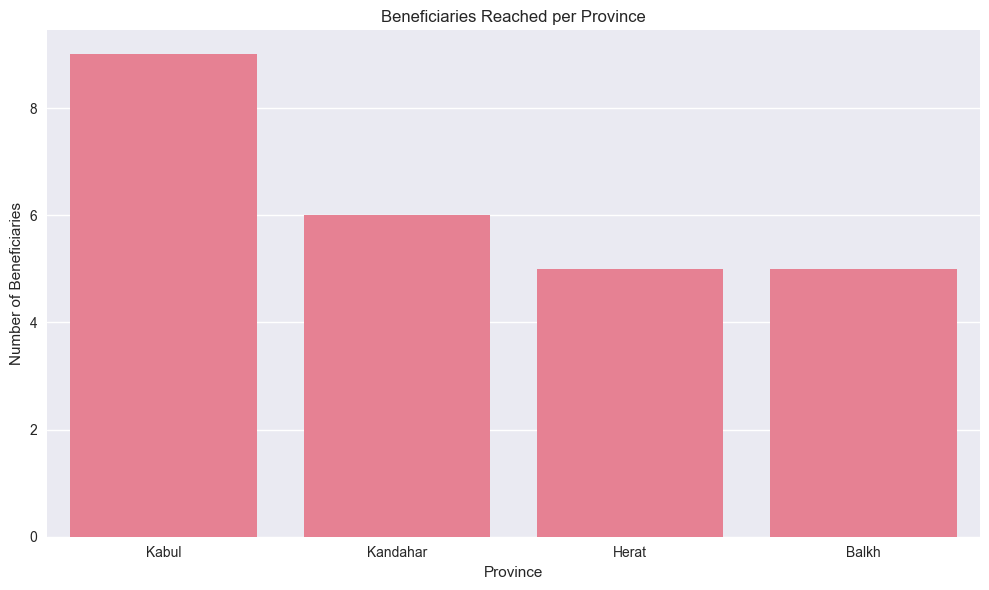

In [11]:
# Count beneficiaries per province
province_counts = df_clean['province'].value_counts()
print(province_counts)

# Visualize
plt.figure()
sns.barplot(x=province_counts.index, y=province_counts.values)
plt.title('Beneficiaries Reached per Province')
plt.xlabel('Province')
plt.ylabel('Number of Beneficiaries')
plt.tight_layout()
plt.show()